# Introduction => PCA

> Principal component analysis is a dimention reduction technique that finds the variance maximizing directions onto which to project the data.

 > Principal components are calculated to reduce variance of features and thus

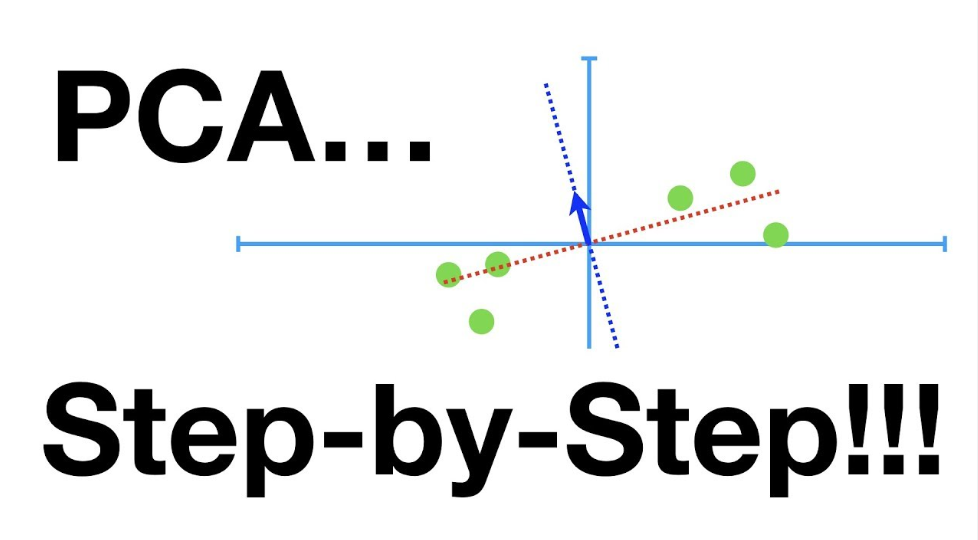

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_regression

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
plt.rc("figure", autolayout=True)
plt.rc(
    "axes",
    labelweight="bold",
    labelsize="large",
    titleweight="bold",
    titlesize=14,
    titlepad=10,
)

این بخش تنظیمات ظاهری نقشه‌نگاری را دگرگون می‌کند تا نمودارها آراسته، خوانا و حرفه‌ای دیده شوند. در آغاز، چیدمان شکل به گونه‌ای ساماندهی می‌شود که همه اجزا بدون روی‌هم‌افتادگی نمایش یابند. سپس ویژگی‌های بخش‌های افقی و عمودی نمودار دگرگون می‌گردد؛ وزن نوشته‌های عنوان و برچسب‌ها پررنگ‌تر می‌شود، اندازه نوشتار برچسب‌ها افزوده می‌گردد، عنوان نمودار در اندازه‌ای درشت‌تر نمایش داده می‌شود و فاصله میان عنوان و نمودار کمی بیشتر می‌شود. نتیجه این دگرگونی‌ها نمودارهایی هماهنگ، خوش‌ساخت و یک‌دست است.

In [ ]:
path = "/content/drive/MyDrive/ford.csv"

In [ ]:
ford = pd.read_csv(path)
ford

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0
...,...,...,...,...,...,...,...,...,...
17960,Fiesta,2016,7999,Manual,31348,Petrol,125,54.3,1.2
17961,B-MAX,2017,8999,Manual,16700,Petrol,150,47.1,1.4
17962,B-MAX,2014,7499,Manual,40700,Petrol,30,57.7,1.0
17963,Focus,2015,9999,Manual,7010,Diesel,20,67.3,1.6


در این بخش تلاش می‌شود پراکندگی ویژگی‌های عددی سنجیده شود. اگر همه ستون‌ها را به شکل یک‌جا بررسی کنیم، کار با شکست روبه‌رو می‌شود زیرا برخی ستون‌ها نوشته‌ای هستند و توانایی سنجش پراکندگی ندارند. برای حل این مسئله، نخست تنها ستون‌هایی برگزیده می‌شوند که ماهیت عددی دارند و از دیگر ستون‌ها جدا می‌گردند. سپس پراکندگی همین ستون‌های عددی محاسبه می‌شود. با این کار از بروز خطا جلوگیری شده و سنجش پراکندگی به شکلی درست و قابل اتکا انجام می‌گیرد.

In [ ]:
# variance among numircal features
# ford.var() => This leads to an error as all variables are NOT numerical

# Select only numeric columns
numeric_cols = ford.select_dtypes(include=['int64', 'float64'])

# Compute variance only on numeric columns
numeric_cols.var()

,0
year,4.203918e+00
price,2.248071e+07
mileage,3.791633e+08
tax,3.845294e+03
mpg,1.025354e+02
engineSize,1.869450e-01


# Plotting continues numerical features

در این بخش نخست ستون بهای خودرو جدا می‌شود تا به عنوان ویژگی وابسته مورد استفاده قرار گیرد. سپس از جدول اصلی نسخه‌ای تازه ساخته می‌شود که ستون بهای خودرو از آن برداشته شده است. پس از آن، فهرستی از ستون‌هایی فراهم می‌شود که ماهیت عددی دارند تا تنها همین ویژگی‌ها برای ترسیم به کار روند. در ادامه، برای هر یک از این ستون‌های عددی یک نقش پراکندگی ساخته می‌شود که در آن رابطه میان هر ویژگی و بهای خودرو دیده می‌شود. این کار به شناخت هماهنگی یا ناهمخوانی میان ویژگی‌ها و بهای خودرو کمک می‌کند و درک بهتری از الگوهای پنهان به دست می‌دهد.

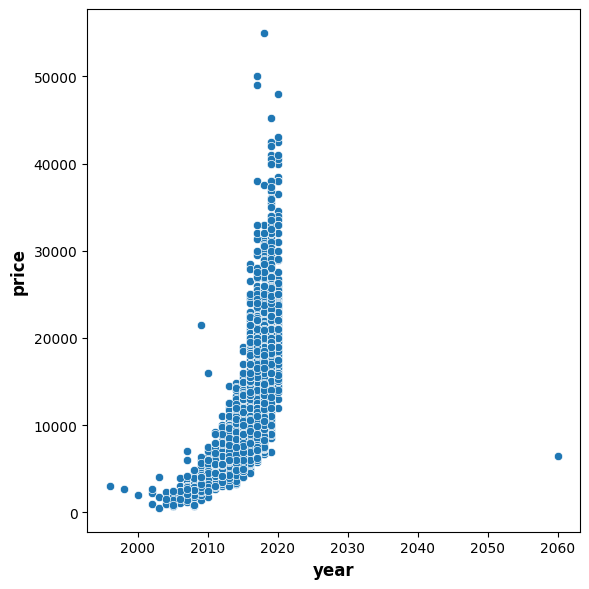

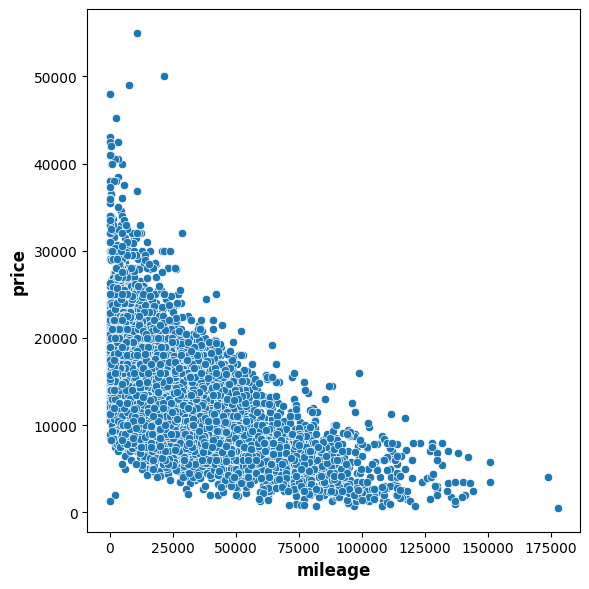

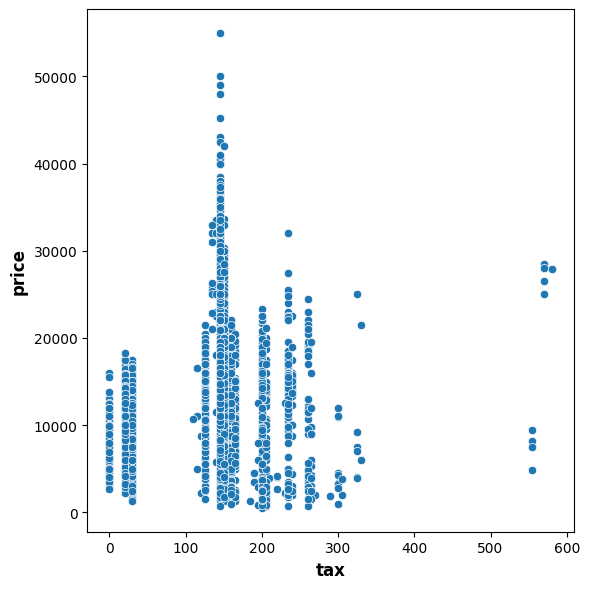

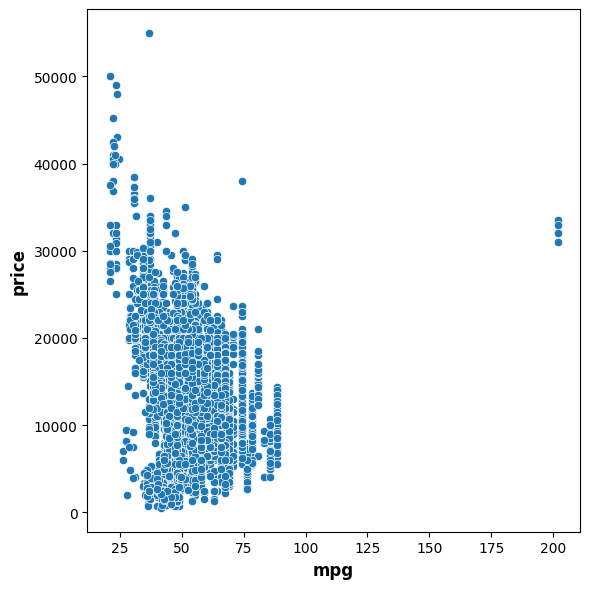

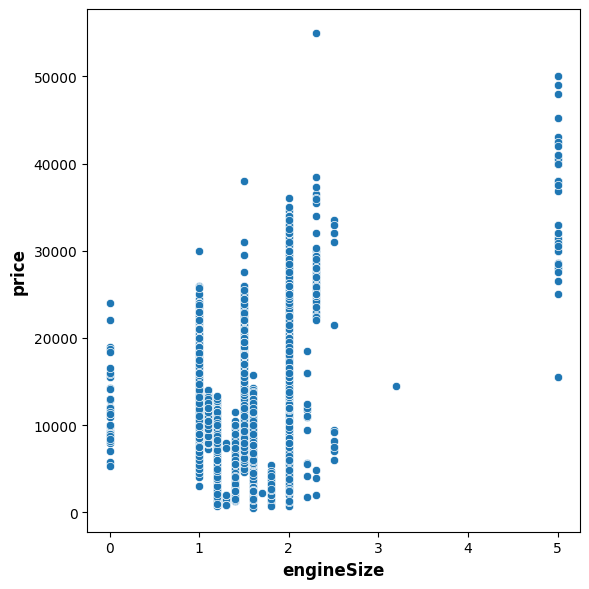

In [ ]:
y = ford['price']
ford_ = ford.drop('price', axis=1)

cols = [col for col in ford_.columns if ford_[col].dtype in ['int64','float64']]

for idx, col in enumerate(cols):
    plt.figure(idx, figsize=(6,6))
    sns.scatterplot(x=col, y=y, data=ford_)
    plt.show

> As per above plots there are some outliears in in dataset which can affect model performance

> We can mileage feature having largest varince among all features

> We will do principal component analysis on this features to reduce variance and and reduce effects  of outliears

# PCA object

در این بخش چند ویژگی عددی از جدول اصلی برگزیده می‌شود تا برای کاهش پیچیدگی و آشکار شدن ساختارهای پنهان به کار رود. نخست بخشی از جدول ساخته می‌شود که تنها همین ویژگی‌ها را در بر دارد. سپس همه این ویژگی‌ها هم‌سنجیده و نرمال می‌شوند تا اثر تفاوت مقیاس از میان برود. پس از آن فرایند تبدیل اجزای بنیادین بر همین داده‌های هم‌سنجیده انجام می‌گیرد و نگاشتی تازه پدید می‌آورد که ساختار پنهان داده‌ها را در قالب چند بعد تازه نشان می‌دهد. در پایان، نتیجه این دگرگونی در قالب یک جدول سامانمند عرضه می‌شود تا بررسی و تفسیر آن آسان گردد.

In [ ]:
features = ['mileage','year','mpg','tax','engineSize']

X = ford_[features]

# normalizing features
X_norm = (X - X.mean(axis=0))/X.std(axis=0)

# principal component analysis on features
pca = PCA()

# fit and transform X_norm to PCA dataframe
X_pca = pca.fit_transform(X_norm)

# converting to dataframe
names = [f"PC{i+1}" for i in range(X_pca.shape[1])]
X_pcadf = pd.DataFrame(X_pca, columns=names)


print(X_pcadf.head())
print("+++++++++++++++++++++++++++++++++++++++++++++++++++")
print("shape of pca df:", X_pcadf.shape)

        PC1       PC2       PC3       PC4       PC5
0 -0.575611 -0.368421 -0.708761  0.371575 -0.224397
1 -1.059305 -0.623569 -0.499118  0.275858 -0.125147
2 -0.679683 -0.423364 -0.687725  0.308659 -0.342023
3 -1.771358  0.858840 -0.159534 -0.833414  0.574171
4 -1.810537 -0.426270 -0.659147 -0.402589  0.187178
+++++++++++++++++++++++++++++++++++++++++++++++++++
shape of pca df: (17965, 5)


در این بخش فرمانی به کار می‌رود که اندازه‌های ویژه به دست آمده از دگرگونی اجزای بنیادین را نمایش می‌دهد. این اندازه‌ها بیانگر نیروی نهفته هر بُعد تازه هستند و نشان می‌دهند هر بُعد تا چه اندازه از پراکندگی داده‌ها را در خود جای می‌دهد. هرچه اندازه ویژه بزرگ‌تر باشد، آن بُعد توان بیشتری در بازنمایی ساختار اصلی داده‌ها دارد. بررسی این مقدارها کمک می‌کند بفهمیم کدام بُعدهای تازه ارزش بیشتری برای نگه‌داری دارند و کدام‌ها نقش اندک‌تری ایفا می‌کنند.

In [ ]:
pca.singular_values_

array([189.10834173, 167.05350962, 113.43209754,  92.58589638,
        68.64525512])

In [ ]:
X_norm.T

,0,1,2,3,4,5,6,7,8,9,...,17955,17956,17957,17958,17959,17960,17961,17962,17963,17964
mileage,-0.381039,-0.733389,-0.560167,-0.662672,-1.123742,0.619777,-1.095650,-0.529456,-0.845806,1.272454,...,-0.837949,-0.950777,1.168819,-0.513793,0.630305,0.410041,-0.342214,0.890318,-0.839849,-0.942714
year,0.065075,0.552798,0.065075,1.040520,1.040520,-0.910370,1.040520,0.065075,1.040520,0.552798,...,0.552798,0.552798,-0.910370,1.040520,-0.422648,-0.422648,0.065075,-1.398093,-0.910370,0.552798
mpg,-0.020442,-0.020442,-0.020442,-1.738794,-0.909245,-0.988249,-0.741360,-0.356212,-1.551158,0.344955,...,-0.909245,-1.067254,-0.454968,-0.909245,1.085624,-0.356212,-1.067254,-0.020442,0.927615,-0.020442
tax,0.591279,0.591279,0.591279,0.510647,0.510647,0.510647,0.510647,0.510647,0.510647,0.510647,...,0.510647,0.510647,0.188121,0.510647,-1.505142,0.188121,0.591279,-1.343879,-1.505142,0.510647
engineSize,-0.811401,-0.811401,-0.811401,0.345012,-0.811401,0.576295,-0.811401,-0.348836,1.501425,-0.811401,...,-0.811401,-0.811401,-0.811401,-0.811401,0.345012,-0.348836,0.113730,-0.811401,0.576295,-0.348836


# PCA from scratch

در این بخش هدف آن است که تحلیل مؤلفه‌های اصلی به صورت دستی و با تکیه بر محاسبات عددی انجام شود. داده‌های هم‌سنجیده شده که در قالب نمره استاندارد هستند به عنوان ورودی به کار می‌روند. نخست، ماتریس هم‌واریانس از روی نسخه جابه‌جا شده این داده‌ها محاسبه می‌شود تا میزان هم‌تغییری هر جفت ویژگی سنجیده گردد. این ماتریس نشان می‌دهد کدام ویژگی‌ها با هم هماهنگ یا ناهمسو تغییر می‌کنند. در پایان، همین ماتریس هم‌واریانس برای بررسی و تفسیر بعدی نمایش داده می‌شود.

In [ ]:
# we will perform PCA from scratch using numpy library
# X_norm is the Z-scoretransformed dataframe in our dataset

# convert cov_matrix from the X_norm
cov_matrix = np.cov(X_norm.T)
print("Convariance matrix: ", cov_matrix)

Convariance matrix:  [[ 1.         -0.70789926  0.12007683 -0.26055045  0.2150014 ]
 [-0.70789926  1.         -0.02296881  0.29845652 -0.13735825]
 [ 0.12007683 -0.02296881  1.         -0.50301254 -0.26052712]
 [-0.26055045  0.29845652 -0.50301254  1.          0.18431146]
 [ 0.2150014  -0.13735825 -0.26052712  0.18431146  1.        ]]


در این بخش بردارهای ویژه و مقدارهای ویژه از دل ماتریس هم‌واریانس به دست آورده می‌شوند. این دو عنصر بنیادی‌ترین بخش تحلیل مؤلفه‌های اصلی هستند. مقدارهای ویژه نشان می‌دهند هر بُعد پنهان چه اندازه از پراکندگی داده‌ها را در خود جای می‌دهد، و بردارهای ویژه جهت هر یک از این بُعدها را روشن می‌کنند. با استفاده از این دو، می‌توان فهمید کدام ترکیب از ویژگی‌ها بیشترین نقش را در ساختار نهفته داده‌ها دارد. در پایان، هر دو بخش برای بررسی و تفسیر بیشتر نمایش داده می‌شوند.

In [ ]:
# from COV_MATRIX calculate eigenvectors and eigenvalues
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print("Eigenvectors:", eigenvectors)
print("Eigenvalues:", eigenvalues)

Eigenvectors: [[ 0.5809945  -0.30672577  0.65666384  0.35123476 -0.11743699]
 [-0.57200807  0.30155231  0.6778961   0.05749211  0.34499929]
 [ 0.3198565   0.55811472 -0.25087814  0.57436467  0.43973307]
 [-0.48160177 -0.39623711 -0.18663366  0.73028686 -0.20713489]
 [ 0.03168146 -0.58863369 -0.10713317 -0.10057401  0.79430096]]
Eigenvalues: [1.99075734 1.55348893 0.2623119  0.47718483 0.716257  ]


در این بخش، جفت‌های مربوط به مقدارهای ویژه و بردارهای ویژه ساخته می‌شود تا بتوان آن‌ها را بر پایه اهمیتشان مرتب کرد. هر جفت، یک مقدار ویژه و بردار ویژه هماهنگ با آن را در بر دارد. این جفت‌ها ابتدا چیده می‌شوند و سپس وارونه می‌گردند تا ترتیب از بیشترین تا کمترین اهمیت فراهم شود. با این کار، مهم‌ترین بُعدهای نهفته در آغاز قرار می‌گیرند. پس از انجام این چیدمان، مقدارهای ویژه و بردارهای ویژه مرتب شده از دل فهرست بیرون کشیده می‌شوند و برای بررسی بیشتر نمایش داده می‌شوند.

In [ ]:
# sort the eigen values and eigen vectors in descending order
eig_pairs = [(eigenvalues[index],eigenvectors[:,index]) for index in range(len(eigenvalues))]

# sort the pairs
eig_pairs.sort()

# reverse to make it in correct order
eig_pairs.reverse()
print(eig_pairs)

# extract the sorted eiganvalues and eiganvectors
eigenvalues_sorted = [eig_pairs[index][0] for index in range(len(eigenvalues))]
eigenvectors_sorted = [eig_pairs[index][1] for index in range(len(eigenvalues))]

# print sorted eigan values
print("Sorted eigan values:", eigenvalues_sorted)

[(np.float64(1.9907573430794159), array([ 0.5809945 , -0.57200807,  0.3198565 , -0.48160177,  0.03168146])), (np.float64(1.5534889266247038), array([-0.30672577,  0.30155231,  0.55811472, -0.39623711, -0.58863369])), (np.float64(0.7162570002651933), array([-0.11743699,  0.34499929,  0.43973307, -0.20713489,  0.79430096])), (np.float64(0.47718482565372217), array([ 0.35123476,  0.05749211,  0.57436467,  0.73028686, -0.10057401])), (np.float64(0.26231190437677343), array([ 0.65666384,  0.6778961 , -0.25087814, -0.18663366, -0.10713317]))]
Sorted eigan values: [np.float64(1.9907573430794159), np.float64(1.5534889266247038), np.float64(0.7162570002651933), np.float64(0.47718482565372217), np.float64(0.26231190437677343)]


In [ ]:
print(eigenvectors_sorted)

[array([ 0.5809945 , -0.57200807,  0.3198565 , -0.48160177,  0.03168146]), array([-0.30672577,  0.30155231,  0.55811472, -0.39623711, -0.58863369]), array([-0.11743699,  0.34499929,  0.43973307, -0.20713489,  0.79430096]), array([ 0.35123476,  0.05749211,  0.57436467,  0.73028686, -0.10057401]), array([ 0.65666384,  0.6778961 , -0.25087814, -0.18663366, -0.10713317])]


در این بخش میزان سهم هر بُعد نهفته از پراکندگی کل داده‌ها سنجیده می‌شود. ابتدا همه مقدارهای ویژه با هم جمع می‌شوند تا میزان پراکندگی کامل به دست آید. سپس سهم هر مقدار ویژه نسبت به این کل محاسبه می‌شود تا روشن شود هر بُعد چه اندازه از ساختار داده را بازنمایی می‌کند. پس از آن، انباشت این سهم‌ها محاسبه می‌شود تا دریابیم چند بُعد نخست چه اندازه از اطلاعات اصلی را پوشش می‌دهند. در پایان، هر دو فهرست برای بررسی بیشتر نمایش داده می‌شوند.

In [ ]:
# plot the variance plots using sorted eigenvalues and eigenvectors
total = sum(eigenvalues_sorted)
var_explained = [(i/total) for i in eigenvalues_sorted]

# calculate cumulative variance
cum_var_exp = np.cumsum(var_explained)
print(var_explained)
print(cum_var_exp)

[np.float64(0.39815146861589845), np.float64(0.3106977853249527), np.float64(0.14325140005304415), np.float64(0.09543696513074809), np.float64(0.0524623808753567)]
[0.39815147 0.70884925 0.85210065 0.94753762 1.        ]


در این بخش داده‌های نرمال‌شده به فضای تازه‌ای برده می‌شوند که بر پایه بُعدهای نهفته ساخته شده است. نخست، بردارهای ویژه مرتب‌شده در قالب یک ساختار عددی کنار هم قرار می‌گیرند تا چارچوب دگرگونی فراهم شود. سپس با انجام ضرب نقطه‌ای میان داده‌های نرمال‌شده و این چارچوب، نمایش تازه‌ای از داده‌ها ساخته می‌شود که هر ستون آن یکی از بُعدهای بنیادین است. این نمایش تازه کمک می‌کند ساختار پنهان داده‌ها آشکارتر شود و امکان تحلیل ساده‌تر و مؤثرتر فراهم آید. در پایان، همین داده‌های دگرگون‌شده در قالب یک جدول سامان‌مند عرضه می‌شود.

In [ ]:
# transforming original dataframe into PCA
vect = np.array(eigenvectors_sorted)

# dot product to create principal components analysis
X_vect_pca = np.dot(X_norm,vect.T)

# pca dataframe
pd.DataFrame(X_vect_pca)

,0,1,2,3,4
0,-0.575611,0.368421,-0.708761,0.371575,-0.224397
1,-1.059305,0.623569,-0.499118,0.275858,-0.125147
2,-0.679683,0.423364,-0.687725,0.308659,-0.342023
3,-1.771358,-0.858840,-0.159534,-0.833414,0.574171
4,-1.810537,0.426270,-0.659147,-0.402589,0.187178
...,...,...,...,...,...
17960,0.264402,-0.321232,-0.666652,0.087592,0.074376
17961,-0.858574,-0.772293,-0.438807,-0.309084,-0.035392
17962,1.931960,0.304023,-0.962019,-0.679221,-0.020253
17963,1.072632,0.757961,0.961974,-0.971680,-1.182183


In [ ]:
X_norm

,mileage,year,mpg,tax,engineSize
0,-0.381039,0.065075,-0.020442,0.591279,-0.811401
1,-0.733389,0.552798,-0.020442,0.591279,-0.811401
2,-0.560167,0.065075,-0.020442,0.591279,-0.811401
3,-0.662672,1.040520,-1.738794,0.510647,0.345012
4,-1.123742,1.040520,-0.909245,0.510647,-0.811401
...,...,...,...,...,...
17960,0.410041,-0.422648,-0.356212,0.188121,-0.348836
17961,-0.342214,0.065075,-1.067254,0.591279,0.113730
17962,0.890318,-1.398093,-0.020442,-1.343879,-0.811401
17963,-0.839849,-0.910370,0.927615,-1.505142,0.576295


In [ ]:
print(vect.T)

[[ 0.5809945  -0.30672577 -0.11743699  0.35123476  0.65666384]
 [-0.57200807  0.30155231  0.34499929  0.05749211  0.6778961 ]
 [ 0.3198565   0.55811472  0.43973307  0.57436467 -0.25087814]
 [-0.48160177 -0.39623711 -0.20713489  0.73028686 -0.18663366]
 [ 0.03168146 -0.58863369  0.79430096 -0.10057401 -0.10713317]]


# Plotting explained variance ratio

در این بخش میزان سهم هر بُعد نهفته از ساختار داده‌ها از دل دگرگونی انجام‌شده بیرون کشیده می‌شود. این سهم‌ها نشان می‌دهند هر بُعد تازه چه اندازه از پراکندگی اصلی را بازنمایی می‌کند. سپس فهرستی از ویژگی‌های آغازین به عنوان نام محور افقی آماده می‌شود تا بتوان نموداری روشن و قابل فهم ساخت. در ادامه، با بهره‌گیری از ابزارهای ترسیمی، ستونی شکل داده می‌شود که در آن سهم هر بُعد در برابر نام ویژگی مربوط به آن نمایش می‌یابد. این نمودار کمک می‌کند اهمیت نسبی هر بُعد به صورت دیداری آشکار شود و بتوان درباره نقش هر ویژگی در شکل‌دهی ساختار نهایی داوری کرد.

[0.39815147 0.31069779 0.1432514  0.09543697 0.05246238]


<function matplotlib.pyplot.show(close=None, block=None)>

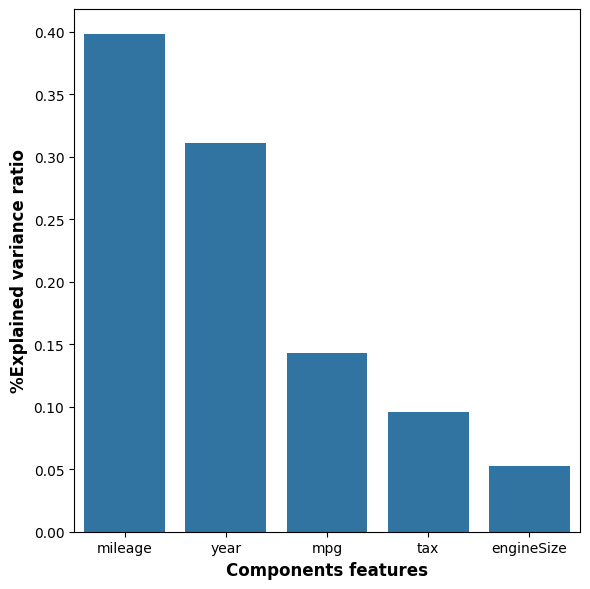

In [ ]:
evr = pca.explained_variance_ratio_
print(evr)
features = ['mileage','year','mpg','tax','engineSize']

# plot the EVR using matplotlib pyplot
plt.figure(figsize=(6,6))
sns.barplot(x=np.array(features), y=evr)
plt.xlabel("Components features")
plt.ylabel("%Explained variance ratio")
plt.show

> Reduced variances of each features after dimentionality reduction

# Plotting explained variance

در این بخش میزان پراکندگی هر بُعد نهفته از دل دگرگونی انجام‌شده بیرون کشیده می‌شود. این مقدارها نشان می‌دهند هر بُعد تازه چه اندازه از تغییرات داده‌های اصلی را در خود نگه می‌دارد. سپس فهرستی از ویژگی‌های آغازین آماده می‌شود تا محور افقی نمودار را شکل دهد. در ادامه، نقش خطی ترسیم می‌شود که در آن میزان پراکندگی هر بُعد در برابر نام ویژگی مربوط نمایش می‌یابد. این نمودار کمک می‌کند شدت سهم هر بُعد از ساختار داده‌ها به صورت روشن دیده شود و درک بهتری از اهمیت نسبی هر ویژگی در شکل‌دهی بُعدهای تازه فراهم آید.

[1.99075734 1.55348893 0.716257   0.47718483 0.2623119 ]


<function matplotlib.pyplot.show(close=None, block=None)>

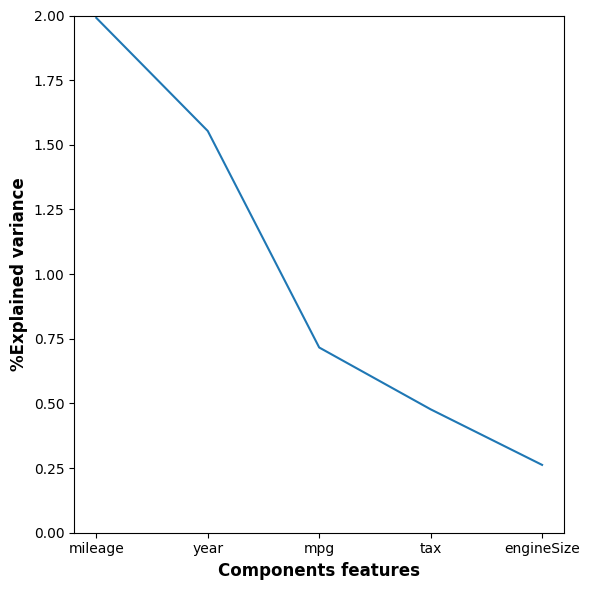

In [ ]:
ev = pca.explained_variance_
print(ev)

features = ['mileage','year','mpg','tax','engineSize']


plt.figure(figsize=(6,6))
sns.lineplot(x=np.array(features), y=ev)
plt.xlabel("Components features")
plt.ylabel("%Explained variance")
plt.ylim(0,2)
plt.show

# Plotting Cummulative explained variance

در این بخش میزان انباشته پراکندگی بُعدهای نهفته محاسبه می‌شود تا روشن گردد با افزودن هر بُعد تازه چه اندازه از ساختار اصلی داده‌ها پوشش داده می‌شود. نخست، مقدارهای پراکندگی یکی پس از دیگری با هم جمع می‌شوند تا نموداری روبه‌بالا پدید آید که نشان می‌دهد چند بُعد نخست چند درصد از اطلاعات را در بر می‌گیرند. سپس فهرستی از ویژگی‌های آغازین برای نام‌گذاری محور افقی آماده می‌شود. در ادامه، نقش خطی ترسیم می‌شود که روند افزایش میزان پوشش را نمایش می‌دهد. این نمودار کمک می‌کند بفهمیم از چه بخشی به بعد افزودن بُعد تازه ارزش چندانی ندارد و بیشتر ساختار داده‌ها پیش از آن پوشش یافته است.

[1.99075734 3.54424627 4.26050327 4.7376881  5.        ]


<function matplotlib.pyplot.show(close=None, block=None)>

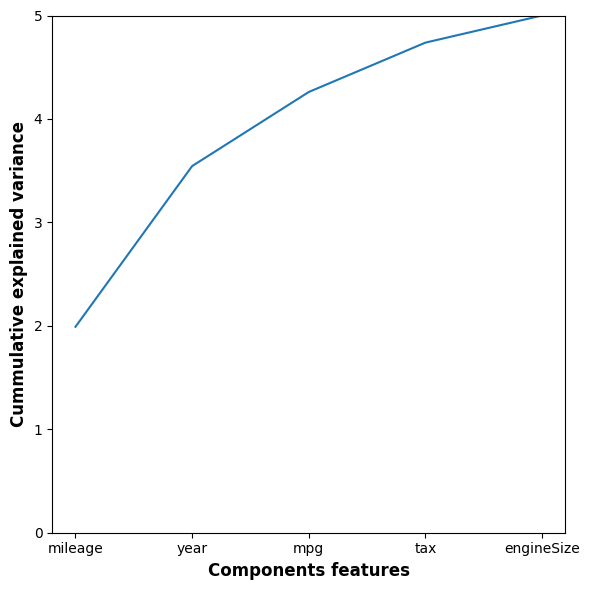

In [ ]:
evc = np.cumsum(pca.explained_variance_)
print(evc)

features = ['mileage','year','mpg','tax','engineSize']


plt.figure(figsize=(6,6))
sns.lineplot(x=np.array(features), y=evc)
plt.xlabel("Components features")
plt.ylabel("Cummulative explained variance")
plt.ylim(0,5)
plt.show

> Cummulative variance is at about 5

در این بخش جدولی ساخته می‌شود که نشان می‌دهد هر ویژگی آغازین چه اندازه بر هر بُعد نهفته اثر می‌گذارد. برای این کار، بردارهای بنیادین دگرگونی در قالب یک ساختار تازه کنار هم قرار می‌گیرند و جایگاه ویژگی‌ها در نقش سطرها و جایگاه بُعدهای نهفته در نقش ستون‌ها تعیین می‌شود. مقدارهای درون جدول بیانگر آن است که هر ویژگی چه سهمی در شکل‌دهی هر بُعد دارد؛ مقدارهای بزرگ‌تر نشانگر اثرگذاری پررنگ‌تر ویژگی بر آن بُعد هستند. این جدول کمک می‌کند رابطه میان ویژگی‌های آغازین و ساختار پنهان داده‌ها به شکلی روشن و قابل تفسیر دیده شود.

In [ ]:
loadings = pd.DataFrame(pca.components_.T ,
                        index=np.array(features),
                        columns=names)

loadings

,PC1,PC2,PC3,PC4,PC5
mileage,0.580994,0.306726,-0.117437,0.351235,0.656664
year,-0.572008,-0.301552,0.344999,0.057492,0.677896
mpg,0.319856,-0.558115,0.439733,0.574365,-0.250878
tax,-0.481602,0.396237,-0.207135,0.730287,-0.186634
engineSize,0.031681,0.588634,0.794301,-0.100574,-0.107133


In [ ]:
pca.noise_variance_

0.0

در این بخش ماتریس هم‌واریانس مربوط به بُعدهای نهفته به دست آورده می‌شود. این ماتریس نشان می‌دهد هر بُعد تازه چگونه با دیگر بُعدها هم‌تغییر می‌کند و میزان هماهنگی یا ناهمسویی میان آن‌ها چگونه است. چون دگرگونی اجزای بنیادین بُعدها را به گونه‌ای می‌سازد که تا حد امکان مستقل از هم باشند، این ماتریس معمولاً مقدارهای ناچیز در بیرون از قطر دارد و بخش اصلی آن بر قطر متمرکز است. نمایش این ماتریس کمک می‌کند درک بهتری از ساختار درونی بُعدهای تازه و میزان وابستگی یا استقلال آن‌ها به دست آید.

In [ ]:
# covariance matrix of principal components
pca.get_covariance()

array([[ 1.        , -0.70789926,  0.12007683, -0.26055045,  0.2150014 ],
       [-0.70789926,  1.        , -0.02296881,  0.29845652, -0.13735825],
       [ 0.12007683, -0.02296881,  1.        , -0.50301254, -0.26052712],
       [-0.26055045,  0.29845652, -0.50301254,  1.        ,  0.18431146],
       [ 0.2150014 , -0.13735825, -0.26052712,  0.18431146,  1.        ]])

در این بخش میزان وابستگی میان بهای خودرو و بُعدهای نهفته سنجیده می‌شود تا روشن گردد هر بُعد تازه چه اندازه توان پیش‌بینی یا توضیح رفتار بهای خودرو را دارد. نخست ستون بهای خودرو جدا می‌شود و سپس سنجش وابستگی اطلاعاتی میان آن و هر یک از بُعدهای نهفته انجام می‌گیرد. این سنجش نشان می‌دهد کدام بُعدها بیشترین آگاهی را درباره رفتار ستون بهای خودرو در خود نگه می‌دارند. در پایان، نتیجه در قالب یک ستون سامان‌مند نمایش داده می‌شود تا بتوان بُعدهای مهم‌تر را به آسانی تشخیص داد.

In [ ]:
y = ford['price']

mi_score = mutual_info_regression(X_pcadf,y, discrete_features=False)
mi_score = pd.Series(mi_score, index=X_pcadf.columns, name="MI_SCORE")

print(mi_score)

PC1    0.536694
PC2    0.342352
PC3    0.337408
PC4    0.239470
PC5    0.110232
Name: MI_SCORE, dtype: float64


> As we can see after PCA, PC1 which has a higest explained varience among all features has the most feature imporatance to predict target variable

# مهم

توضیح جامع و یکپارچه از کل فرایند

در این برنامه، هدف آن است که مجموعه‌ای از ویژگی‌های عددی مرتبط با خودرو را به شکلی دگرگون کنیم که بتوان ساختار پنهان داده‌ها را بهتر فهمید، پیچیدگی را کاهش داد و در نهایت رابطه هر بُعد پنهان را با بهای خودرو سنجید. کل فرایند از چند گام به هم پیوسته تشکیل شده است که هر کدام بخشی از مسیر تحلیل را روشن‌تر و قابل تفسیرتر می‌کند.

در آغاز، داده‌های مربوط به خودرو بررسی می‌شوند و ستون بهای خودرو به عنوان ویژگی وابسته جدا می‌گردد. سپس از میان ویژگی‌های موجود، تنها آن‌هایی که ماهیت عددی دارند انتخاب می‌شوند تا بتوان تحلیل مؤلفه‌های بنیادین را انجام داد؛ زیرا این تحلیل نیازمند داده‌هایی است که در قالب مقدارهای پیوسته و قابل سنجش باشند. پس از جدا شدن این ویژگی‌ها، داده‌ها هم‌سنجیده و نرمال می‌شوند. نرمال‌سازی بخش مهمی از این تحلیل است، زیرا اختلاف مقیاس میان ویژگی‌ها می‌تواند نتیجه را مخدوش کند. وقتی همه ویژگی‌ها حول میانگین خود متمرکز شده و پراکندگی یکسانی پیدا می‌کنند، نقش هر ویژگی در ساختار نهایی عادلانه و قابل مقایسه می‌شود.

پس از آماده‌سازی داده‌ها، فرایند تحلیل مؤلفه‌های بنیادین آغاز می‌شود. این تحلیل تلاش دارد مجموعه ویژگی‌های آغازین را در قالب چند بُعد تازه نمایش دهد؛ بعدهایی که ترکیب وزن‌دار ویژگی‌های اصلی هستند و هر یک بیشترین مقدار ممکن از پراکندگی داده‌ها را در خود نگه می‌دارند. این فرایند معمولاً با محاسبه ماتریس هم‌واریانس آغاز می‌شود. ماتریس هم‌واریانس نشان می‌دهد هر جفت ویژگی چگونه با یکدیگر هم‌تغییر می‌کنند؛ برای نمونه اگر افزایش یک ویژگی همواره با افزایش ویژگی دیگر همراه باشد، مقدار هم‌واریانس میان آن‌ها بزرگ خواهد بود. این ماتریس در حقیقت نقطه آغاز استخراج ساختار پنهان داده‌هاست.

در مرحله بعد، مقدارهای ویژه و بردارهای ویژه از دل ماتریس هم‌واریانس بیرون کشیده می‌شوند. مقدارهای ویژه نشان‌دهنده میزان پراکندگی است که هر بُعد تازه می‌تواند توضیح دهد، و بردارهای ویژه جهت این بُعدها را تعیین می‌کنند. پس از استخراج این مقدارها، همه آن‌ها بر پایه اهمیت مرتب می‌شوند تا بتوان مهم‌ترین بُعدها را در آغاز قرار داد. این ترتیب‌بندی سبب می‌شود که روند تحلیل معنادارتر شود، زیرا بُعدهای مهم‌تر سهم بیشتری در بازنمایی داده‌ها دارند و معمولاً تنها چند بُعد نخست بخش قابل توجهی از ساختار اصلی داده‌ها را پوشش می‌دهند.

وقتی این بُعدهای تازه آماده شدند، مرحله دگرگونی داده‌ها آغاز می‌شود. داده‌های نرمال‌شده در چارچوب بردارهای ویژه جای می‌گیرند و نگاشتی تازه از مجموعه داده پدید می‌آورند که در آن هر ستون یک بُعد بنیادین است. این نمایش تازه در حقیقت شکل ساده‌شده و ساختارمندتری از داده‌هاست و امکان می‌دهد الگوهایی را که در فضای ویژگی‌های اصلی پیچیده بوده‌اند آسان‌تر مشاهده کنیم.

در ادامه، میزان سهم هر بُعد پنهان در بازنمایی داده‌ها سنجیده و نمایش داده می‌شود. این کار به کمک مقایسه مقدارهای ویژه انجام می‌شود. زمانی که سهم هر بُعد نسبت به مجموع پراکندگی داده‌ها محاسبه می‌شود، روشن می‌گردد کدام بُعد بیشترین اطلاعات را حمل می‌کند. سپس پراکندگی انباشته نیز بررسی می‌شود تا مشخص گردد چند بُعد نخست چه اندازه از ساختار کلی را کنار هم در بر می‌گیرند. این سنجش کمک می‌کند تصمیم بگیریم چه تعداد بُعد برای ادامه تحلیل کافی است.

پس از آن، جدول بارگذاری ساخته می‌شود. این جدول نشان می‌دهد هر ویژگی آغازین چه اندازه بر هر بُعد بنیادین تاثیر می‌گذارد. مقدارهای بزرگ‌تر بیانگر آن هستند که آن ویژگی نقش پررنگ‌تری در شکل‌دهی آن بُعد دارد. این مرحله یکی از مهم‌ترین بخش‌های تحلیل است، زیرا کمک می‌کند رابطه میان ویژگی‌های اصلی و ساختار پنهان داده‌ها را بفهمیم. برای نمونه ممکن است دیده شود که یک بُعد مشخص عمدتاً از ترکیب ویژگی‌های مرتبط با توان موتور و تاریخ تولید تشکیل شده است، در حالی که بُعدی دیگر بیشتر از ویژگی‌هایی مانند پیمایش و بهای مالیاتی تاثیر گرفته است.

در پایان، میزان وابستگی میان هر بُعد بنیادین و بهای خودرو سنجیده می‌شود. این سنجش با استفاده از شاخص وابستگی اطلاعاتی انجام می‌گیرد، که بیان می‌کند هر بُعد چه اندازه آگاهی درباره رفتار بهای خودرو در خود نگه می‌دارد. اگر بُعدی مقدار وابستگی بالایی داشته باشد، نشان می‌دهد که آن بُعد توان پیش‌بینی یا توضیح مناسبی درباره تغییرات قیمت دارد. این مرحله تحلیل را برای کاربردهای مدل‌سازی و پیش‌بینی بسیار ارزشمند می‌کند، زیرا روشن می‌سازد که کدام مؤلفه‌های بنیادین اهمیت بیشتری برای مدل‌های بعدی خواهند داشت.

در مجموع، این برنامه از آماده‌سازی داده‌ها آغاز می‌شود، با استخراج ساختار پنهان ادامه می‌یابد، سپس دگرگونی داده‌ها و بررسی سهم هر بُعد انجام می‌شود، و در پایان رابطه مؤلفه‌های پنهان با بهای خودرو بررسی می‌گردد. نتیجه این فرایند شناختی عمیق‌تر از داده‌ها و فراهم شدن بستری مناسب برای مدل‌سازی و تحلیل‌های پیشرفته‌تر است.

Comprehensive Explanation of the Entire Code (High-Level, No Line-by-Line Details)
This code performs a complete workflow for preparing numerical data, applying Principal Component Analysis, validating the mathematical steps manually, and finally examining the relationship between the extracted components and the target variable. The objective is to simplify the feature space, uncover latent structure, and understand how each transformed component contributes to explaining the variation in car prices.
The process begins by separating the price column, which serves as the dependent variable in later analysis. From the remaining dataset, only numerical features are selected, since PCA requires continuous quantitative variables. These features include engine size, model year, mileage, fuel efficiency, and tax. Once isolated, the selected numerical data is standardized. Standardization is necessary because features originally exist on different scales; without normalization, features with larger numeric ranges would dominate the PCA results. By centering each variable around its mean and scaling it by its standard deviation, all features contribute fairly to the transformation.
After preprocessing, PCA is performed. PCA aims to discover new axes, called principal components, that capture the maximum amount of variance in the data. Each component is a weighted linear combination of the original features. The central insight behind PCA is that complex, high-dimensional data often contains underlying patterns that can be represented more compactly without a significant loss of information. The first component captures the greatest variance, the second captures the next highest amount under the constraint of being orthogonal to the first, and so on.
The first mathematical step in PCA is computing the covariance matrix of the normalized data. This matrix expresses how pairs of features co-vary—whether they increase together, move in opposite directions, or behave independently. Once the covariance matrix is built, its eigenvalues and eigenvectors are extracted. The eigenvalues represent the amount of variance captured by each principal component, while the eigenvectors define the directions of those components in the feature space.
After extracting eigenvalues and eigenvectors, they are sorted in descending order because the components with the highest eigenvalues are the most important. These sorted eigenvectors form a transformation matrix that is used to project the normalized data into the new PCA space. This projection produces a transformed dataset where each column corresponds to a principal component rather than an original feature. This new representation simplifies the structure of the dataset and makes relationships between patterns easier to analyze.
Next, the amount of variance explained by each principal component is computed. The explained variance ratio indicates how much information each component retains relative to the total variance in the dataset. Visualization of the individual and cumulative explained variance helps determine how many components are necessary to preserve most of the dataset’s structure. Often, the first few components capture the majority of the information, making it possible to reduce dimensionality without significant information loss.
The code then constructs a loadings matrix, which shows the contribution of each original feature to each principal component. Loadings help interpret the components by highlighting which features have the strongest influence. A large positive or negative loading value indicates that a feature strongly contributes to that particular component. This allows us to understand, for example, whether a component is mainly related to mileage and engine power, or instead strongly associated with model year and tax.
Finally, the relationship between the principal components and the car price is evaluated using mutual information. This metric measures how much information about the price is contained in each component. Components with higher mutual information are more relevant for predicting price. This final step bridges unsupervised feature extraction with supervised learning by showing which components carry the most predictive power.
Overall, the code executes the full PCA process: preparing data, normalizing features, computing PCA both through built-in functions and manual mathematical steps, analyzing explained variance, interpreting component loadings, and linking components to the target variable. This end-to-end workflow provides a deep understanding of the structure hidden within the data and offers a strong foundation for future modeling or predictive analysis.